In [1]:
from os import makedirs
import os

# print(os.environ)
from typing import Dict, List, Tuple

import torch
from torch.utils.data import DataLoader
from torch.nn.utils import parameters_to_vector

import argparse
from archs import load_architecture
from utilities import get_loss_and_acc, compute_losses, \
    save_files, save_files_final, get_hessian_eigenvalues, make_base_directory, iterate_dataset
from data import load_dataset, DATASETS, take_first
import dataclasses
import NGD
import tracemalloc
import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = "cifar10"
arch_id = "cnn-relu"
loss = "ce"
max_steps = 5000
model_params = NGD.EmpiricalNGD.Params(
    lr = 0.0001,
    fisher_batch_size=100,
    physical_batch_size=128,
    epsilon= 1e-5,
    gradient_batch_size=128
)
seed = 0

train_dataset, test_dataset = load_dataset(dataset, loss)

directory = f"{make_base_directory(dataset, arch_id, loss)}/seed_{seed}/ngd/{model_params.get_dirname()}"
print(f"Loading from {directory}")

Loading from /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.0001__fisher_bs_100__phys_bs_128__epsilon_1e-05__gradient_bs_128


In [6]:
model = load_architecture(arch_id, dataset)
model.load_state_dict(torch.load(f"{directory}/snapshot_final", map_location="cpu"))
model.to("cpu")
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=2048, out_features=10, bias=True)
)

In [5]:
class datapoint:
    def __init__(self, model_probs, emp_FIM_diag, FIM_diag, loss_v, class_id):
        # self.emp_FIM_diag = emp_FIM_diag
        # self.FIM_diag = FIM_diag
        self.loss_v = loss_v
        self.class_id = class_id
        self.emp_FIM_diag_norm = torch.sqrt(torch.sum(torch.stack([torch.sum(f**2) for f in emp_FIM_diag])))
        self.FIM_diag_norm = torch.sqrt(torch.sum(torch.stack([torch.sum(f**2) for f in FIM_diag])))
        self.correct = torch.argmax(model_probs, dim=1) == class_id

def calc_datapoint(X, y, model, activation_fn, params, device = "cuda", num_classes = 10):
    X = X.to(device)
    y = y.to(device)
    class_id = round(y.item())//1
    y = torch.nn.functional.one_hot(y, num_classes=num_classes).float().to(device)
    # print(y.device, X.device)
    model_logits = model(X)

    if activation_fn is not None:
        model_probs = activation_fn(model_logits)
    else:
        model_probs = model_logits
    
    llh = torch.sum(model_probs * y, dim=1)
    true_label_llh = torch.log(llh + params.epsilon)
    grads = torch.autograd.grad(true_label_llh, model.parameters(), retain_graph=False)
    
    emp_FIM_diag = [grad**2 for grad in grads]

    FIM_diag = [torch.zeros_like(param) for param in model.parameters()]
            
    for cl in range(num_classes):
        model_logits = model(X)  # fresh forward pass
        if activation_fn:
            model_probs = activation_fn(model_logits)
        else:
            model_probs = model_logits

        likeh = model_probs[0][cl]
        cl_loglikeh = torch.log(likeh + params.epsilon)
        # print(f"Calculating Fisher for class {cl} with likeh {likeh.item()}")
        
        grads = torch.autograd.grad(cl_loglikeh, model.parameters(), retain_graph=False)
        for j, param in enumerate(model.parameters()):
            FIM_diag[j] += likeh * (grads[j] ** 2)


    return datapoint(
        model_probs,
        emp_FIM_diag,
        FIM_diag,
        true_label_llh.to("cpu"),
        class_id
    )
    

def calc_fisher_diag_dict(
    dataset,
    params: NGD.EmpiricalNGD.Params,
    device: str = "cpu", 
    activation_fn= torch.nn.Softmax(dim=1),
    ):
    
    result = []

    for i, (X, y) in enumerate(tqdm.tqdm(iterate_dataset(dataset, 1), total=len(dataset), desc="Calculating Fisher Diagonal")):    
        # if i % 100 == 0:
        #     snapshot = tracemalloc.take_snapshot()
            # top_stats = snapshot.statistics('lineno')

        #     print("[ Top 10 memory consumers ]")
        #     for stat in top_stats[:10]:
        #         print(stat)
        result.append(calc_datapoint(X, y, model, activation_fn, params, device))
        # torch.cpu.empty_cache()
        # torch.cuda.empty_cache()
        
    return result

In [7]:
datapoints = calc_fisher_diag_dict(
    test_dataset,
    model_params,
    device="cpu",
)

Calculating Fisher Diagonal: 100%|██████████| 10000/10000 [02:05<00:00, 79.53it/s]


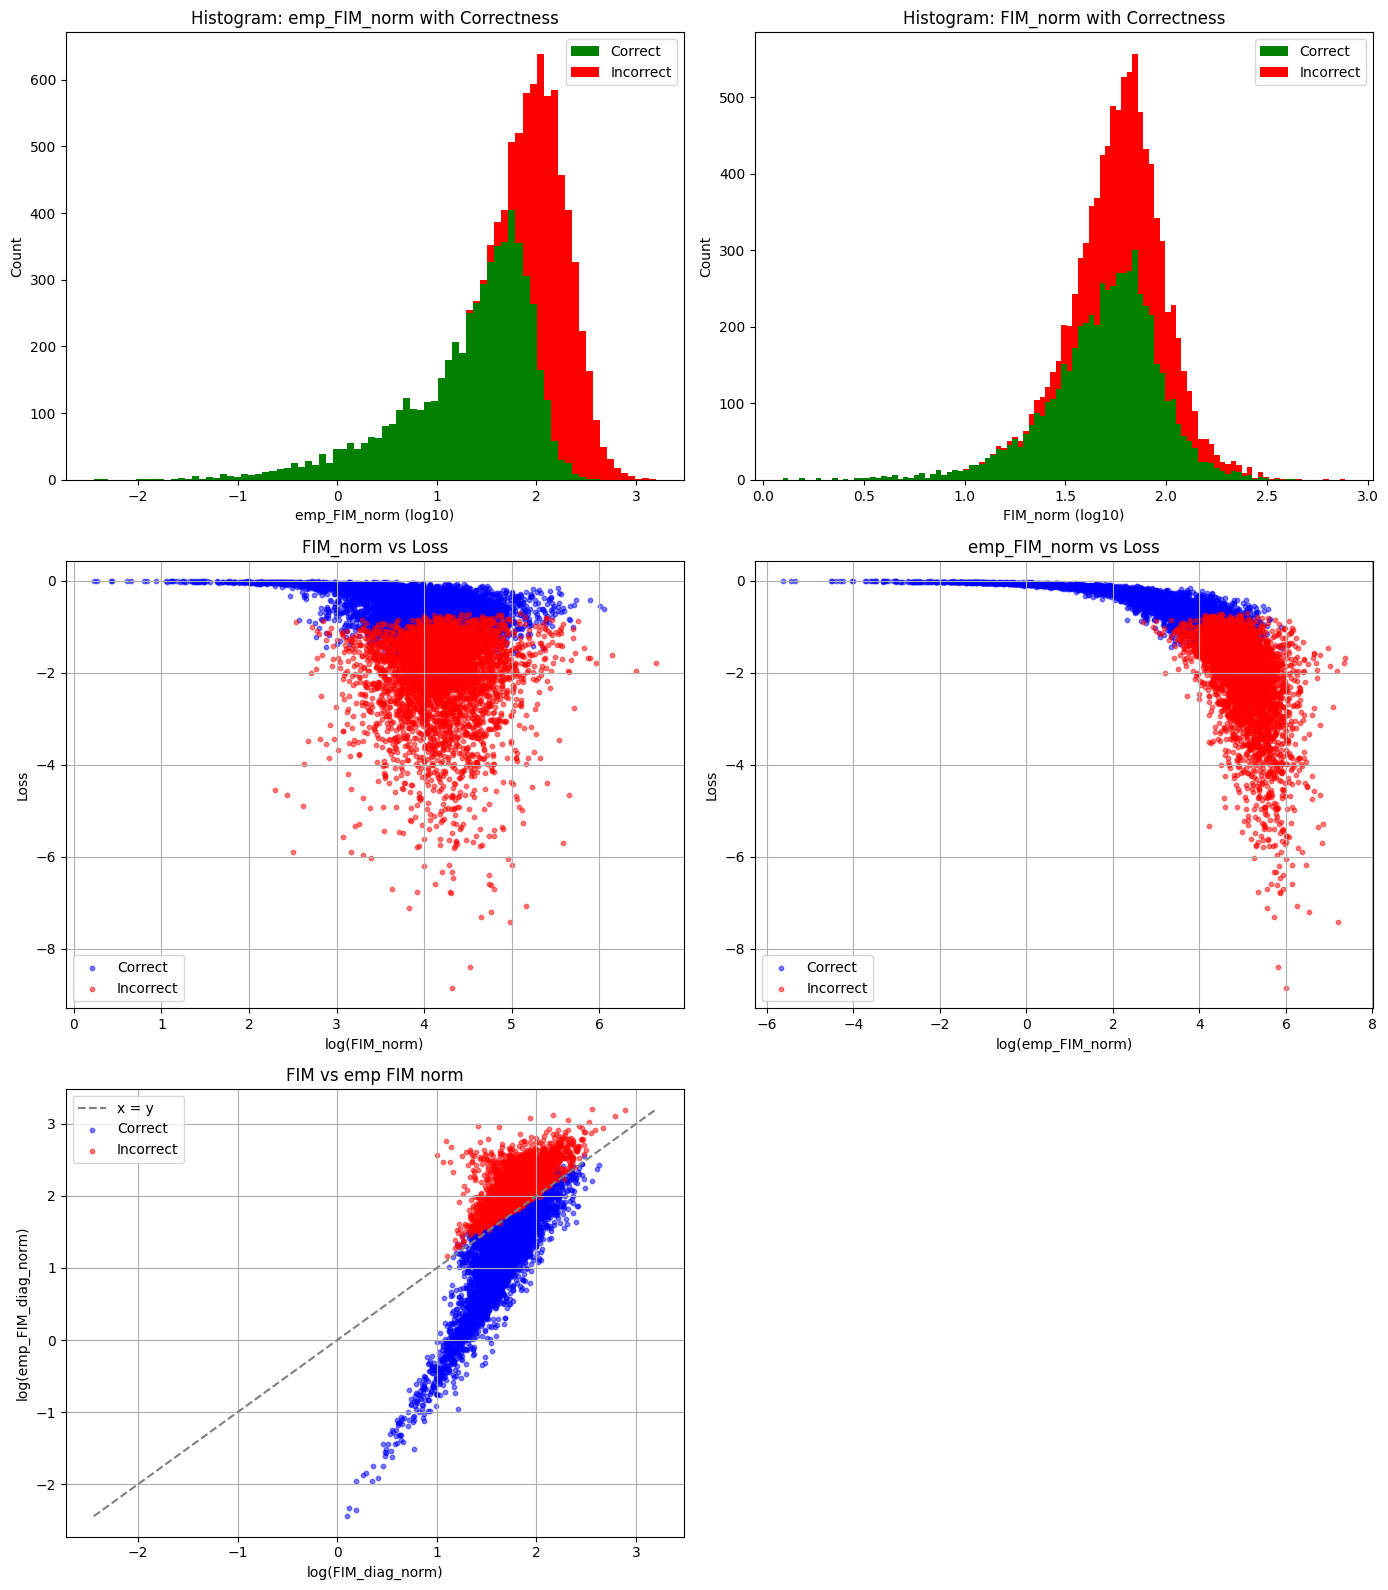

: 

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(14, 16))
axs = axs.flatten()

# Plot 1: Histogram with emp_FIM_diag_norm
fim_norms = torch.tensor([np.log10(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct for dp in datapoints])
bins = np.histogram_bin_edges(fim_norms, bins='auto')
correct_hist, _ = np.histogram(fim_norms[correct_flags], bins=bins)
incorrect_hist, _ = np.histogram(fim_norms[~correct_flags], bins=bins)
bar_widths = np.diff(bins)
x_pos = bins[:-1]
axs[0].bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
axs[0].bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')
axs[0].set_xlabel('emp_FIM_norm (log10)')
axs[0].set_ylabel('Count')
axs[0].set_title('Histogram: emp_FIM_norm with Correctness')
axs[0].legend()

# Plot 2: Histogram with FIM_diag_norm
fim_norms = torch.tensor([np.log10(dp.FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct for dp in datapoints])
bins = np.histogram_bin_edges(fim_norms, bins='auto')
correct_hist, _ = np.histogram(fim_norms[correct_flags], bins=bins)
incorrect_hist, _ = np.histogram(fim_norms[~correct_flags], bins=bins)
bar_widths = np.diff(bins)
x_pos = bins[:-1]
axs[1].bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
axs[1].bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')
axs[1].set_xlabel('FIM_norm (log10)')
axs[1].set_ylabel('Count')
axs[1].set_title('Histogram: FIM_norm with Correctness')
axs[1].legend()

# Plot 3: FIM_diag_norm vs Loss
fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([dp.loss_v.item() for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])
correct_mask = correct_flags
incorrect_mask = ~correct_mask
axs[2].scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[2].scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[2].set_xlabel('log(FIM_norm)')
axs[2].set_ylabel('Loss')
axs[2].set_title('FIM_norm vs Loss')
axs[2].legend()
axs[2].grid(True)

# Plot 4: emp_FIM_diag_norm vs Loss
fim_norms = torch.tensor([np.log(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([dp.loss_v.item() for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])
correct_mask = correct_flags
incorrect_mask = ~correct_mask
axs[3].scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[3].scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[3].set_xlabel('log(emp_FIM_norm)')
axs[3].set_ylabel('Loss')
axs[3].set_title('emp_FIM_norm vs Loss')
axs[3].legend()
axs[3].grid(True)

# Plot 5: FIM_diag_norm vs emp_FIM_diag_norm
fim_norms = torch.tensor([np.log10(dp.FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([np.log10(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])
correct_mask = correct_flags
incorrect_mask = ~correct_mask
min_val = min(fim_norms.min(), losses.min()).item()
max_val = max(fim_norms.max(), losses.max()).item()
axs[4].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='x = y')
axs[4].scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', label='Correct')
axs[4].scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', label='Incorrect')
axs[4].set_xlabel('log(FIM_diag_norm)')
axs[4].set_ylabel('log(emp_FIM_diag_norm)')
axs[4].set_title('FIM vs emp FIM norm')
axs[4].legend()
axs[4].grid(True)

fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])
emp_fim_norms = torch.tensor([np.log(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([dp.loss_v.item() for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])
diffs = fim_norms - emp_fim_norms

axs[5].scatter(diffs[correct_flags], losses[correct_flags], alpha=0.5, s=10, color='blue', label='Correct')
axs[5].scatter(diffs[~correct_flags], losses[~correct_flags], alpha=0.5, s=10, color='red', label='Incorrect')
axs[5].axvline(0, linestyle='--', color='gray', linewidth=1)
axs[5].set_xlabel('log(FIM_diag_norm) - log(emp_FIM_diag_norm)')
axs[5].set_ylabel('Loss')
axs[5].set_title('Difference in FIM Norms vs Loss')
axs[5].legend()
axs[5].grid(True)

plt.tight_layout()
plt.show()


tensor([ True, False,  True,  ...,  True,  True,  True])


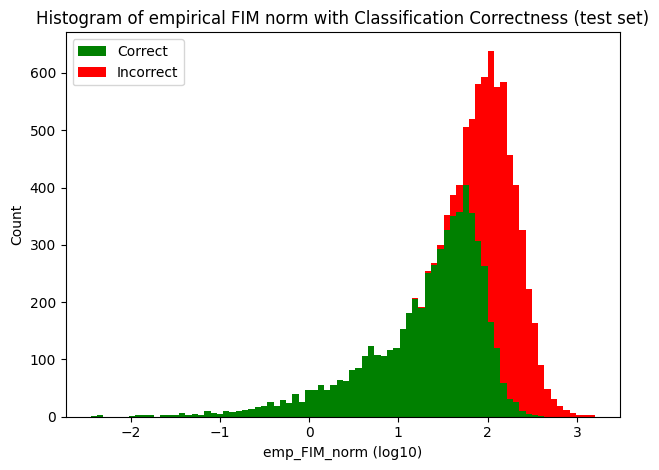

In [6]:
fim_norms = torch.tensor([np.log10(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct for dp in datapoints])
print(correct_flags)

bins = np.histogram_bin_edges(fim_norms, bins='auto')
correct_hist, _ = np.histogram(fim_norms[correct_flags], bins=bins)
incorrect_hist, _ = np.histogram(fim_norms[~correct_flags], bins=bins)

bar_widths = np.diff(bins)
x_pos = bins[:-1]

plt.bar(x_pos, correct_hist, width=bar_widths, label='Correct', color='green', align='edge')
plt.bar(x_pos, incorrect_hist, bottom=correct_hist, width=bar_widths, label='Incorrect', color='red', align='edge')

plt.xlabel('emp_FIM_norm (log10)')
plt.ylabel('Count')
# plt.xscale('log')
plt.title('Histogram of empirical FIM norm with Classification Correctness (test set)')
plt.legend()
plt.tight_layout()
plt.show()


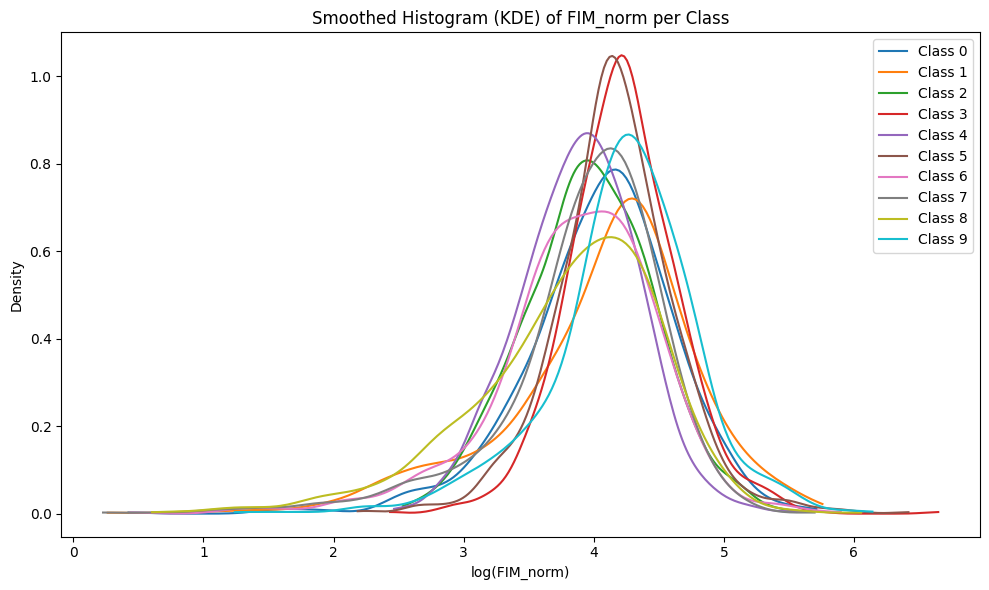

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Extract class_ids and FIM norms
class_ids = torch.tensor([dp.class_id for dp in datapoints])
fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])  # log for visualization

plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors  # 10 distinct colors

for class_id in range(10):
    # Filter FIM_norms by class
    class_mask = class_ids == class_id
    class_fims = fim_norms[class_mask].numpy()

    if len(class_fims) > 1:
        # Estimate density
        kde = gaussian_kde(class_fims)
        x_vals = np.linspace(class_fims.min(), class_fims.max(), 200)
        y_vals = kde(x_vals)
        plt.plot(x_vals, y_vals, label=f'Class {class_id}', color=colors[class_id])
    else:
        print(f"Class {class_id} has too few samples for KDE")

plt.xlabel('log(FIM_norm)')
plt.ylabel('Density')
plt.title('Smoothed Histogram (KDE) of FIM_norm per Class')
plt.legend()
plt.tight_layout()
plt.show()


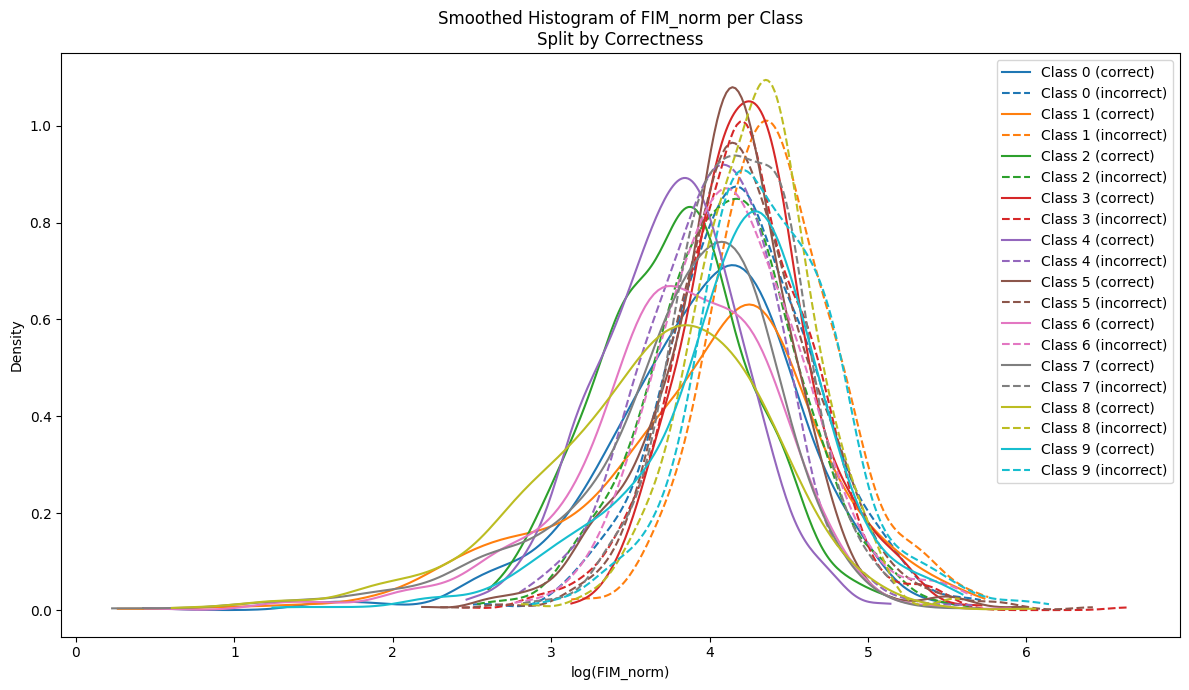

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Extract data
fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])
class_ids = torch.tensor([dp.class_id for dp in datapoints])

plt.figure(figsize=(12, 7))
colors = plt.cm.tab10.colors  # 10 colors for 10 classes

for class_id in range(10):
    class_mask = class_ids == class_id

    # Split into correct and incorrect
    class_correct = fim_norms[class_mask & correct_flags].numpy()
    class_incorrect = fim_norms[class_mask & ~correct_flags].numpy()

    # KDE for correct
    if len(class_correct) > 1:
        kde_c = gaussian_kde(class_correct)
        x_vals = np.linspace(class_correct.min(), class_correct.max(), 200)
        y_vals = kde_c(x_vals)
        plt.plot(x_vals, y_vals, label=f'Class {class_id} (correct)', color=colors[class_id], linestyle='-')

    # KDE for incorrect
    if len(class_incorrect) > 1:
        kde_ic = gaussian_kde(class_incorrect)
        x_vals = np.linspace(class_incorrect.min(), class_incorrect.max(), 200)
        y_vals = kde_ic(x_vals)
        plt.plot(x_vals, y_vals, label=f'Class {class_id} (incorrect)', color=colors[class_id], linestyle='--')

plt.xlabel('log(FIM_norm)')
plt.ylabel('Density')
plt.title('Smoothed Histogram of FIM_norm per Class\nSplit by Correctness')
plt.legend()
plt.tight_layout()
plt.show()


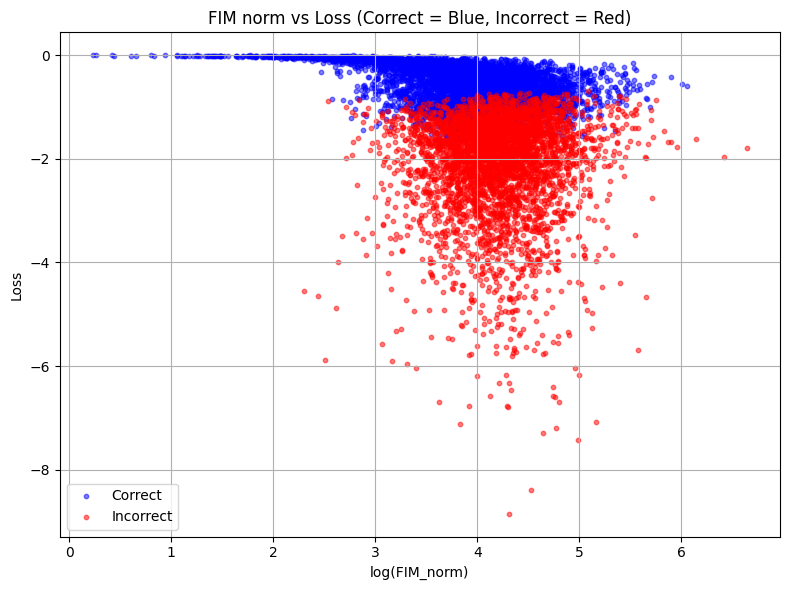

In [9]:
fim_norms = torch.tensor([np.log(dp.FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([dp.loss_v.item() for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])

# Create mask
correct_mask = correct_flags
incorrect_mask = ~correct_mask

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', 
            # edgecolors='k',
            label='Correct')
plt.scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', 
            # edgecolors='k',
            label='Incorrect')

plt.xlabel('log(FIM_norm)')
plt.ylabel('Loss')
plt.title('FIM norm vs Loss (Correct = Blue, Incorrect = Red)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


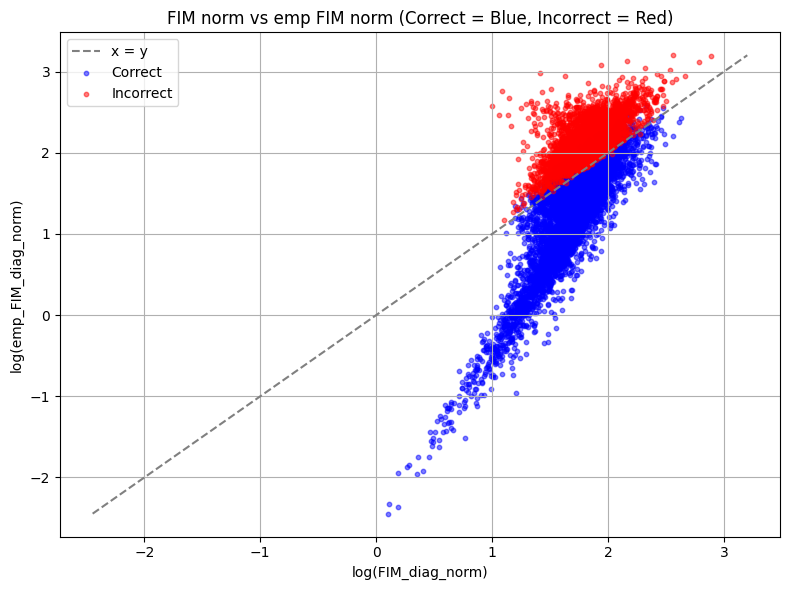

In [16]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Extract values
fim_norms = torch.tensor([np.log10(dp.FIM_diag_norm.item()) for dp in datapoints])
losses = torch.tensor([np.log10(dp.emp_FIM_diag_norm.item()) for dp in datapoints])
correct_flags = torch.tensor([dp.correct.item() for dp in datapoints])

# Create mask
correct_mask = correct_flags
incorrect_mask = ~correct_mask

# Plot
plt.figure(figsize=(8, 6))

min_val = min(fim_norms.min(), losses.min()).item()
max_val = max(fim_norms.max(), losses.max()).item()
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='x = y')


plt.scatter(fim_norms[correct_mask], losses[correct_mask], alpha=0.5, s=10, color='blue', 
            # edgecolors='k',
            label='Correct')

plt.scatter(fim_norms[incorrect_mask], losses[incorrect_mask], alpha=0.5, s=10, color='red', 
            # edgecolors='k',
            label='Incorrect')


plt.xlabel('log(FIM_diag_norm)')
plt.ylabel('log(emp_FIM_diag_norm)')
plt.title('FIM norm vs emp FIM norm (Correct = Blue, Incorrect = Red)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'all_norms_log' is not defined

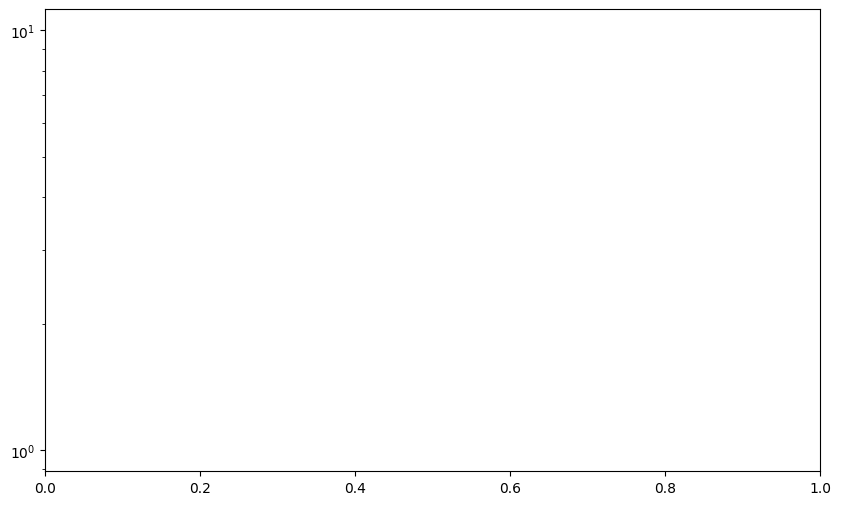

In [11]:
import matplotlib.pyplot as plt

# histogram of all norms with log scale
plt.figure(figsize=(10, 6))
# plt.xscale('log')
plt.yscale('log')
plt.hist(all_norms_log, bins=100, alpha=0.5, color='blue')
plt.title("Fisher Diagonal Norms")
plt.xlabel("Norm")
plt.ylabel("Frequency")


In [ ]:
for (X, y) in iterate_dataset(test_dataset, 10):
    X = X.cuda()
    y = y.cuda()
    print(model(X).shape)
    print(f"X shape: {X.shape}, y shape: {y.shape}")

torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shape: torch.Size([10])
torch.Size([10, 10])
X shape: torch.Size([10, 3, 32, 32]), y shap